# **Business Problem:** The company is losing a significant portion of its customers to churn. Help the company identify and retain at-risk customers early to reduce churn and maximize customer lifetime value?

# 1. Data Loading

In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Reading the CSV file in a Dataframe

df = pd.read_csv('Customer Churn.csv', encoding = 'utf-8')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


# 2. Data Inspection

In [47]:
# 1. Printing the first 10 rows

df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [48]:
# 2. Shape of Dataframe

print(df.shape)

(7043, 21)


In [49]:
# 3. Columns in Dataframe

print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


In [50]:
# 4. Data Types in Dataframe

print(df.dtypes)

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [51]:
# 5. Quick Summary of Dataframe

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [52]:
# 6. Statistical Summary of Numerical Columns

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [53]:
# 7. Count of Churned and Unchurned Customers

print(df['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


# 3. Data Cleaning

In [54]:
#  3.1 TotalCharges column has ' ', so replace it with 0 and changed its Data Type.

df["TotalCharges"] = df["TotalCharges"].replace(' ', 0)
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [55]:
# Re-checking -> For ensuring the changes made in Dataframe

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [56]:
# 3.2 Updating SeniorCitizen Column's value from 1,0 to Yes,No and changing its dt from object to str

def conv(value):
    if value == 1:
        return 'Yes'
    else:
        return 'No'
df['SeniorCitizen'] = df['SeniorCitizen'].apply(conv)

df['SeniorCitizen'] = df['SeniorCitizen'].astype('str')

In [57]:
# Re-checking -> For ensuring the changes made in Dataframe

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   str    
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [58]:
# 3.3 Looking for NULLs in Dataframe

# Count of NULLs in columns
df.isnull().sum()

# Count of Overall NULLs in Dataframe
df.isnull().sum().sum()

np.int64(0)

In [59]:
# 3.4 Checking for Duplicates

# For complete duplicate rows -> Count
df.duplicated().sum()

# For duplicacy in customerID column -> Count
df['customerID'].duplicated().sum()

np.int64(0)

In [60]:
# Renaming columns in Dataframe

df = df.rename(columns={'gender': 'Gender', 'tenure' : 'Tenure'})
print('Both columns renamed !!')

Both columns renamed !!


# 4. Data Manipulation

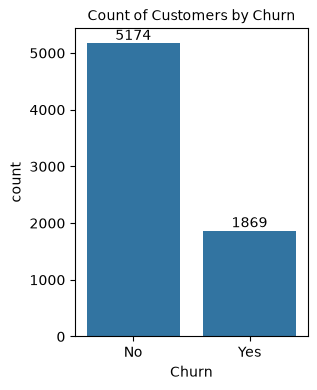

In [61]:
# 1. Churn Customers Count

plt.figure(figsize = (3, 4))
ax = sns.countplot(x = 'Churn', data = df)
ax.bar_label(ax.containers[0])
plt.title('Count of Customers by Churn', fontsize = 10)
plt.show()

# => 1,869 customers churned out of 7,043 total.

TypeError: savefig() missing 1 required positional argument: 'fname'

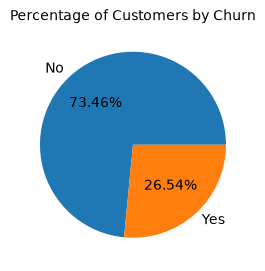

In [62]:
# Churn Customers Percentage

plt.figure(figsize = (3,4))
gb = df.groupby('Churn').agg({'Churn' : 'count'})
plt.pie(gb['Churn'], labels=gb.index, autopct = "%1.2f%%")
plt.title('Percentage of Customers by Churn', fontsize = 10)
plt.savefig()
plt.show()

# => 26.54% of Customers have Churned out yet.

In [ ]:
# 2. Churned Customers Count by Gender

plt.figure(figsize = (3, 4))
ax = sns.countplot(x = df['Gender'], data = df, hue = 'Churn')
ax.bar_label(ax.containers[0])
plt.title('Count of Customers by Gender', fontsize = 9)
plt.show()

# => Churn rate is nearly identical across Genders, suggesting Gender is not a meaningful churn driver.

In [ ]:
# 3. Count of Customers by Senior Citizens

plt.figure(figsize = (3, 4))
plt.title('Churned Customers by Senior Citizens', fontsize = 9)
ax = sns.countplot(x = df['SeniorCitizen'], data = df)
ax.bar_label(ax.containers[0])
plt.show()

In [ ]:
# Churned Customers Count by Senior Citizens

ct = pd.crosstab(df['SeniorCitizen'], df['Churn'])

# Convert each SeniorCitizen group to percentage
ct_percent = ct.div(ct.sum(axis=1), axis=0) * 100

# Plot
ax = ct_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(5, 4)
)

plt.title('Churn Percentage by Senior Citizen', fontsize=10)
plt.xlabel('Senior Citizen')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.legend(title='Churn')

# Percentage labels
for container in ax.containers:
    labels = [
        f'{v:.2f}%' if v > 0 else ''
        for v in container.datavalues
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type='center',
        fontsize=8
    )
plt.legend(title='Churn')
plt.tight_layout()
plt.savefig()
plt.show()

# => 41.68% of Senior Citizens have Churned

In [ ]:
# 4. Count of Churned Customers by Contract and Tenure

plt.title('Churned Customers by Contract and Tenure', fontsize = 9)
ax = sns.countplot(x = 'Contract', data = df, hue = 'Churn')
ax.bar_label(ax.containers[0])
plt.legend(title = 'Churn')
plt.savefig()
plt.show()

# => Month-to-month contracts have dramatically higher churn than One-year or Two-year contracts.

In [ ]:
# Histplot Churned Customers by Tenure and Contract

sns.displot(
    data=df,
    x='Tenure',
    hue='Churn',
    col='Contract',
    bins=50,
    height=4,
    aspect=1
)
plt.subplots_adjust(top=0.85)
plt.suptitle('Churned Customers by Tenure, Split by Contract Type')
plt.show()

# => Month-to-month customers churn heavily within their first year, with churn risk highest in the earliest months

In [ ]:
# 5. Count of Customers by various other services

cols = ['PhoneService', 'MultipleLines', 'InternetService',
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
        'StreamingTV', 'StreamingMovies']

fig, axes = plt.subplots(3, 3, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = sns.countplot(x=col, data=df, ax=axes[i])
    ax.bar_label(ax.containers[0])
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

In [ ]:
# Count of Churned Customers and Unchurned Customers by various other services

cols = ['PhoneService', 'MultipleLines', 'InternetService',
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
        'StreamingTV', 'StreamingMovies']

fig, axes = plt.subplots(3, 3, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = sns.countplot(x=col, data=df, hue='Churn', ax=axes[i])
    ax.bar_label(ax.containers[0])
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig()
plt.show()

# => **InternetService** — Fiber optic users churn at 41.9%, more than double DSL users (19.0%) and far above customers with no internet (7.4%). This is a major red flag — investigate whether it's pricing, service reliability, or competition specific to fiber customers.

# => **OnlineSecurity** — Customers without this add-on churn at 41.8%, vs. just 14.6% for those who have it. One of the strongest retention levers in the dataset — actively promoting/bundling OnlineSecurity could meaningfully cut churn.

# => **OnlineBackup — Without:** 39.9% churn vs. With: 21.5% churn. Another strong lever — customers without backup service are nearly 2x more likely to leave.

# => **DeviceProtection — Without:** 39.1% churn vs. With: 22.5% churn. Same pattern — lack of this add-on correlates with higher churn risk.

# => **TechSupport — Without:** 41.6% churn vs. With: 15.2% churn. This is your strongest single add-onpredictor — customers lacking tech support churn nearly 3x more than those who have it.

# **Conclusion:** The pattern is clear: support and protection services (TechSupport, OnlineSecurity, OnlineBackup, DeviceProtection) have the strongest link to retention — customers without them churn at roughly 2-3x the rate of those with them. Streaming add-ons (TV, Movies) barely move the needle. And Fiber optic internet users are a high-risk segment worth investigating separately, since the service type itself (not an add-on) is driving churn there.

In [ ]:
# 6. Count of Churned Customers by PaymentMethod
plt.figure(figsize = (10, 3))
plt.title('Count of Customers by Payment Method', fontsize = 10)
ax = sns.countplot(x = 'PaymentMethod', data = df, hue = 'Churn')
ax.bar_label(ax.containers[0])
plt.legend(title='Churn')
plt.show()

# => Customers using Electronic Check are highly likely to Churn

In [ ]:
# 7. Churned Customers by Tenure Grouping

# Bucket Tenure into ranges
bins = [0, 12, 24, 48, 100]
labels = ['0-12', '13-24', '25-48', '49+']
df['Tenure_group'] = pd.cut(df['Tenure'], bins=bins, labels=labels)

# Churn rate (%) within each Tenure bucket
ct = pd.crosstab(df['Tenure_group'], df['Churn'], normalize='index') * 100

# Plot as a stacked bar chart
ax = ct.plot(kind='bar', stacked=True, figsize=(6, 5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', label_type='center')

plt.title('Churn Rate by Tenure Group', fontsize=10)
plt.ylabel('Percentage')
plt.xlabel('Tenure Group (months)')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.savefig()
plt.show()

# => Churn risk is heavily concentrated in the first year — customers with 0-12 months Tenure churn at 47.7%, roughly 5x the rate of customers with 49+ months Tenure (9.5%).

In [ ]:
# 8. Monthly Charges Distribution by Churn Status

plt.figure(figsize=(5, 4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges by Churn Status', fontsize=10)
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()

# => Churned customers tend to pay higher monthly charges than retained customers, as shown by their higher median and 25th percentile in the boxplot.

In [ ]:
# 9. Summary of Average Tenure, Monthly Charges, and Total Charges by Churn Status

summary = df.groupby('Churn').agg({
    'Tenure': 'mean',
    'MonthlyCharges': 'mean',
    'TotalCharges': 'mean'
}).round(2)

print(summary)

# *Churned customers have roughly half the tenure (18 vs 37.6 months) and higher monthly charges (74.44 vs 61.27), but retained customers generate far more total revenue (2,549.91 vs 1,531.80) due to their longer tenure.

# * People who leave (churn) tend to be newer customers — they've been around for about 18 months on average, compared to 37.6 months for people who stay.
# * They also pay a bit more per month (74.44) than the customers who stick around (61.27).
# * But even though they pay more monthly, because they leave so much sooner, the company ends up earning way less money from them overall (1,531.80) compared to loyal customers who stay longer and rack up more total spending over time (2,549.91).

# **Key Findings**

# * Overall churn rate: 26.54% of customers have churned (1,869 out of 7,043) — roughly 1 in 4 customers leave.
# * Tenure: Churn risk drops sharply the longer someone stays — 47.7% churn in the first year vs. just 9.5% after 49+ months.
# * Contract type: The single biggest driver — Month-to-month customers churn far more than One-year or Two-year customers, and most of that churn happens within their first year.
# * Add-on services: Customers without TechSupport, OnlineSecurity, OnlineBackup, or DeviceProtection churn 2-3x more than those who have them. Streaming TV/Movies barely matter.
# * Internet service: Fiber optic users churn at 41.9% — more than double DSL users (19%).
# * Monthly charges: Churned customers pay more per month (74.44 vs 61.27) — but stay for about half as long (18 vs 37.6 months), so they generate far less total revenue (1,531.80 vs 2,549.91).
# * Senior citizens: Churn much more — 41.68% vs. the overall average of 26.54%.
# * Payment method: Electronic Check users churn the most.
# * Gender: No real impact — churn is nearly identical across genders.

# **Suggestions**
# * Target the first 12 months with proactive retention outreach (check-ins, onboarding support, loyalty perks) — this is where churn risk is highest.
# * Incentivize longer contracts — offer discounts or perks to convert Month-to-month customers into One-year or Two-year plans.
# * Bundle protective add-ons — actively promote TechSupport and OnlineSecurity (free trial period or discounted bundle) since customers without them churn 2-3x more.
# * Investigate Fiber optic service specifically — high churn there may point to pricing, reliability, or competitor issues unique to that service.
# * Review pricing for high-paying customers — since churned customers pay more, consider loyalty discounts or value-add perks for customers on higher-priced plans to reduce price-driven churn.
# * Prioritize senior citizens in retention programs — this group churns nearly 1.5x the average rate and may benefit from simplified support or tailored service plans.
# * Encourage other payment methods — investigate why Electronic Check users churn more (possibly linked to Month-to-month, non-committal customers) and nudge them toward automatic payment methods, which may correlate with more stable, long-term customers.

# **This analysis identifies contract type, tenure, and lack of protective services as the primary churn drivers — giving the business clear, actionable levers to reduce churn and improve customer retention.**